In [8]:
## Configuración

# En esta sección se importan las librerías necesarias y se configura la conexión a la base de datos MariaDB para cargar la información en DataFrames de pandas.

In [9]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sqlalchemy import create_engine


load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

In [10]:
## Crear conexión con MariaDB

# Se crea una conexión utilizando SQLAlchemy para facilitar la carga de información hacia DataFrames de pandas.

In [11]:
connection_string = (
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(connection_string)

In [12]:
## Verificar la conexión

# Se realiza una consulta sencilla para comprobar que la conexión a la base de datos fue establecida correctamente.

In [13]:
pd.read_sql("SELECT DATABASE() AS database_name;", engine)

,database_name
0,ag_db


In [14]:
# Carga de datos

# Se cargan las tablas de la base de datos en DataFrames de pandas para realizar el análisis solicitado.

In [15]:
companies_df = pd.read_sql("SELECT * FROM companies;", engine).rename(
    columns={
        "id": "company_id",
        "name": "company_name",
    }
)

programs_df = pd.read_sql("SELECT * FROM programs;", engine).rename(
    columns={
        "id": "program_id",
        "name": "program_name",
    }
)

statuses_df = pd.read_sql("SELECT * FROM statuses;", engine).rename(
    columns={
        "id": "status_id",
        "code": "status_code",
        "name": "estatus",
        "description": "descripcion_estatus",
    }
)

students_df = pd.read_sql("SELECT * FROM students;", engine).rename(
    columns={
        "id": "student_id",
        "created_at": "student_created_at",
        "updated_at": "student_updated_at",
    }
)

enrollments_df = pd.read_sql("SELECT * FROM enrollments;", engine).rename(
    columns={
        "id": "enrollment_id",
        "created_at": "enrollment_created_at",
        "updated_at": "enrollment_updated_at",
    }
)

status_history_df = pd.read_sql("SELECT * FROM status_history;", engine).rename(
    columns={
        "id": "history_id",
    }
)

In [16]:
## Verificación de datos

# Se muestran las primeras filas de cada DataFrame para verificar que la información fue cargada correctamente.

In [17]:
display(
    companies_df.rename(
        columns={
            "company_id": "id_empresa",
            "company_name": "empresa",
        }
    ).head()
)
display(
    programs_df.rename(
        columns={
            "program_id": "id_programa",
            "program_name": "programa",
        }
    ).head()
)
display(statuses_df.head())
display(
    students_df.rename(
        columns={
            "student_id": "id_estudiante",
            "first_name": "nombre",
            "last_name": "apellido",
            "company_id": "id_empresa",
            "student_created_at": "creado_en",
            "student_updated_at": "actualizado_en",
        }
    ).head()
)
display(
    enrollments_df.rename(
        columns={
            "enrollment_id": "id_inscripcion",
            "student_id": "id_estudiante",
            "program_id": "id_programa",
            "status_id": "id_estatus",
            "enrollment_date": "fecha_inscripcion",
            "enrollment_created_at": "creado_en",
            "enrollment_updated_at": "actualizado_en",
        }
    ).head()
)
display(
    status_history_df.rename(
        columns={
            "history_id": "id_historial",
            "enrollment_id": "id_inscripcion",
            "previous_status_id": "id_estatus_anterior",
            "new_status_id": "id_estatus_nuevo",
            "changed_at": "fecha_cambio",
            "reason": "motivo",
        }
    ).head()
)

,id_empresa,empresa,created_at,updated_at
0,1,Alpura,2026-06-28 06:23:57,2026-06-28 06:23:57
1,2,Bayer,2026-06-28 06:23:57,2026-06-28 06:23:57
2,3,Coppel,2026-06-28 06:23:57,2026-06-28 06:23:57
3,4,Soriana,2026-06-28 06:23:57,2026-06-28 06:23:57


,id_programa,programa,created_at,updated_at
0,1,Lic. Administración,2026-06-28 06:23:57,2026-06-28 06:23:57
1,2,Lic. Contaduría,2026-06-28 06:23:57,2026-06-28 06:23:57
2,3,Lic. Logística,2026-06-28 06:23:57,2026-06-28 06:23:57
3,4,Lic. Negocios,2026-06-28 06:23:57,2026-06-28 06:23:57
4,5,Maestría en Dirección,2026-06-28 06:23:57,2026-06-28 06:23:57


,status_id,status_code,estatus,descripcion_estatus
0,1,ENROLLED,Inscrito,Student enrollment has been registered.
1,2,ACTIVE,Activo,Student is currently active.
2,3,SUSPENDED,Suspendido,Student is temporarily suspended.
3,4,COMPANY_LEAVE,Baja empresa,Student left due to company-related reasons.
4,5,PROGRAM_LEAVE,Baja programa,Student voluntarily left the academic program.


,id_estudiante,nombre,apellido,id_empresa,creado_en,actualizado_en
0,1001,Luis,Cruz,4,2026-06-28 06:23:57,2026-06-28 06:23:57
1,1002,Andrés,Ramírez,3,2026-06-28 06:23:57,2026-06-28 06:23:57
2,1003,Daniela,Ortiz,4,2026-06-28 06:23:57,2026-06-28 06:23:57
3,1004,Luis,Reyes,4,2026-06-28 06:23:57,2026-06-28 06:23:57
4,1005,Sofía,Hernández,4,2026-06-28 06:23:57,2026-06-28 06:23:57


,id_inscripcion,id_estudiante,id_programa,id_estatus,fecha_inscripcion,creado_en,actualizado_en
0,1,1001,4,2,2025-02-26,2026-06-28 06:23:57,2026-06-28 06:23:57
1,2,1002,2,3,2022-10-04,2026-06-28 06:23:57,2026-06-28 06:23:57
2,3,1003,3,7,2017-10-02,2026-06-28 06:23:57,2026-06-28 06:23:57
3,4,1004,3,7,2015-06-06,2026-06-28 06:23:57,2026-06-28 06:23:57
4,5,1005,3,5,2017-03-31,2026-06-28 06:23:57,2026-06-28 06:23:57


,id_historial,id_inscripcion,id_estatus_anterior,id_estatus_nuevo,fecha_cambio,motivo
0,1,1,1,2,2025-03-01 09:00:00,Proceso de onboarding completado
1,2,2,1,2,2022-10-10 08:30:00,Inicio de actividades académicas
2,3,2,2,3,2026-06-08 06:23:57,Documentación requerida pendiente
3,4,3,1,2,2017-10-09 09:00:00,Inicio de actividades académicas
4,5,3,2,7,2021-07-15 12:00:00,Programa completado con éxito


In [18]:
## Construcción del DataFrame principal

# Se combinan las tablas principales para facilitar los análisis posteriores.

In [19]:
main_df = (
    enrollments_df
    .merge(students_df, on="student_id")
    .merge(companies_df, on="company_id")
    .merge(programs_df, on="program_id")
    .merge(statuses_df, on="status_id")
)

In [20]:
## Vista previa del DataFrame principal

# Se verifica el resultado de la integración de las tablas.

In [21]:
main_df[
    [
        "student_id",
        "first_name",
        "last_name",
        "company_name",
        "program_name",
        "estatus",
        "enrollment_date",
    ]
].rename(
    columns={
        "student_id": "id_estudiante",
        "first_name": "nombre",
        "last_name": "apellido",
        "company_name": "empresa",
        "program_name": "programa",
        "estatus": "estatus",
        "enrollment_date": "fecha_inscripcion",
    }
).head()

,id_estudiante,nombre,apellido,empresa,programa,estatus,fecha_inscripcion
0,1001,Luis,Cruz,Soriana,Lic. Negocios,Activo,2025-02-26
1,1002,Andrés,Ramírez,Coppel,Lic. Contaduría,Suspendido,2022-10-04
2,1003,Daniela,Ortiz,Soriana,Lic. Logística,Egresado,2017-10-02
3,1004,Luis,Reyes,Soriana,Lic. Logística,Egresado,2015-06-06
4,1005,Sofía,Hernández,Soriana,Lic. Logística,Baja programa,2017-03-31


In [22]:
# Análisis 1 - Distribución de estatus por programa

# Se calcula la distribución del estatus actual de los estudiantes para cada programa académico utilizando una tabla pivote.

In [23]:
status_distribution = pd.pivot_table(
    main_df,
    index="program_name",
    columns="estatus",
    values="student_id",
    aggfunc="count",
    fill_value=0
).rename_axis(index="programa", columns="estatus")

status_distribution

estatus,Activo,Baja empresa,Baja programa,Egresado,Suspendido
programa,,,,,
Lic. Administración,0,1,0,0,0
Lic. Contaduría,0,0,0,0,2
Lic. Logística,0,0,2,7,0
Lic. Negocios,1,3,1,0,0
Maestría en Dirección,0,0,1,0,0
Maestría en Educación,0,0,0,0,1
Secundaria Abierta,0,0,1,0,0


In [24]:
# Análisis 2 - Evolución mensual de altas y bajas

# Se analiza la cantidad de estudiantes que ingresaron al estado activo y aquellos que causaron baja en cada mes, utilizando el historial de cambios de estatus.

In [25]:
month_names = {
    1: "enero",
    2: "febrero",
    3: "marzo",
    4: "abril",
    5: "mayo",
    6: "junio",
    7: "julio",
    8: "agosto",
    9: "septiembre",
    10: "octubre",
    11: "noviembre",
    12: "diciembre",
}

monthly_status = status_history_df.merge(
    statuses_df[["status_id", "status_code"]],
    left_on="new_status_id",
    right_on="status_id",
    how="left",
)

monthly_status["mes"] = pd.to_datetime(
    monthly_status["changed_at"],
    errors="coerce",
).dt.to_period("M")

monthly_status = monthly_status[monthly_status["mes"].notna()]

monthly_trend = (
    monthly_status.assign(
        new_active=(monthly_status["status_code"] == "ACTIVE").astype(int),
        dropouts=monthly_status["status_code"].isin(
            ["COMPANY_LEAVE", "PROGRAM_LEAVE"]
        ).astype(int),
    )
    .groupby("mes", as_index=True)[["new_active", "dropouts"]]
    .sum()
)

if not monthly_trend.empty:
    full_months = pd.period_range(
        monthly_trend.index.min(),
        monthly_trend.index.max(),
        freq="M",
    )
    monthly_trend = monthly_trend.reindex(full_months, fill_value=0)
    monthly_trend.index = [
        f"{month_names[month.month]} {month.year}"
        for month in monthly_trend.index.to_timestamp()
    ]
else:
    monthly_trend.index = []

monthly_trend = monthly_trend.rename(
    columns={
        "new_active": "altas_activas",
        "dropouts": "bajas",
    }
).rename_axis("mes")

monthly_trend

,altas_activas,bajas
mes,,
abril 2015,1,0
mayo 2015,0,0
junio 2015,1,0
julio 2015,1,0
agosto 2015,0,0
...,...,...
febrero 2026,0,0
marzo 2026,0,0
abril 2026,0,0


In [26]:
## Análisis 3. Tasa de estudiantes activos por programa

# Este análisis calcula el porcentaje de estudiantes con estatus **ACTIVE** respecto al total de inscritos en cada programa académico.

In [27]:
program_activity = (
    main_df
    .groupby("program_name")
    .agg(
        total_estudiantes=("student_id", "count"),
        estudiantes_activos=("status_code", lambda x: (x == "ACTIVE").sum())
    )
)

program_activity["tasa_activa"] = (
    program_activity["estudiantes_activos"]
    / program_activity["total_estudiantes"]
    * 100
).round(2)

program_activity = program_activity.rename_axis("programa")
program_activity.sort_values("tasa_activa", ascending=False)

,total_estudiantes,estudiantes_activos,tasa_activa
programa,,,
Lic. Negocios,5,1,20.0
Lic. Contaduría,2,0,0.0
Lic. Administración,1,0,0.0
Lic. Logística,9,0,0.0
Maestría en Dirección,1,0,0.0
Maestría en Educación,1,0,0.0
Secundaria Abierta,1,0,0.0


In [28]:
## Análisis 4. Motivo de baja más frecuente

# Se analizan únicamente los registros cuyo nuevo estatus corresponde a una baja por empresa o baja de programa para identificar cuál es el motivo de baja más frecuente registrado en el historial.

In [29]:
dropout_reasons = (
    status_history_df
    .merge(
        statuses_df[["status_id", "status_code"]],
        left_on="new_status_id",
        right_on="status_id",
        how="left"
    )
    .query("status_code in ['COMPANY_LEAVE', 'PROGRAM_LEAVE']")
    .groupby("reason")
    .size()
    .reset_index(name="total")
    .rename(columns={"reason": "motivo"})
    .sort_values("total", ascending=False)
)

dropout_reasons

,motivo,total
0,Baja asistencia académica,1
1,Baja voluntaria del programa,1
2,Contrato laboral finalizado,1
3,El estudiante decidió abandonar el programa,1
4,El estudiante solicitó su baja,1
5,La empresa ya no patrocina el programa,1
6,Motivos personales,1
7,Reestructuración de la empresa,1
8,Relación laboral finalizada,1


In [30]:
## Visualización 1. Distribución de estatus por programa

# Se genera una gráfica de barras apiladas para visualizar la distribución de estatus de los estudiantes en cada programa académico, permitiendo comparar la composición de estados entre programas.

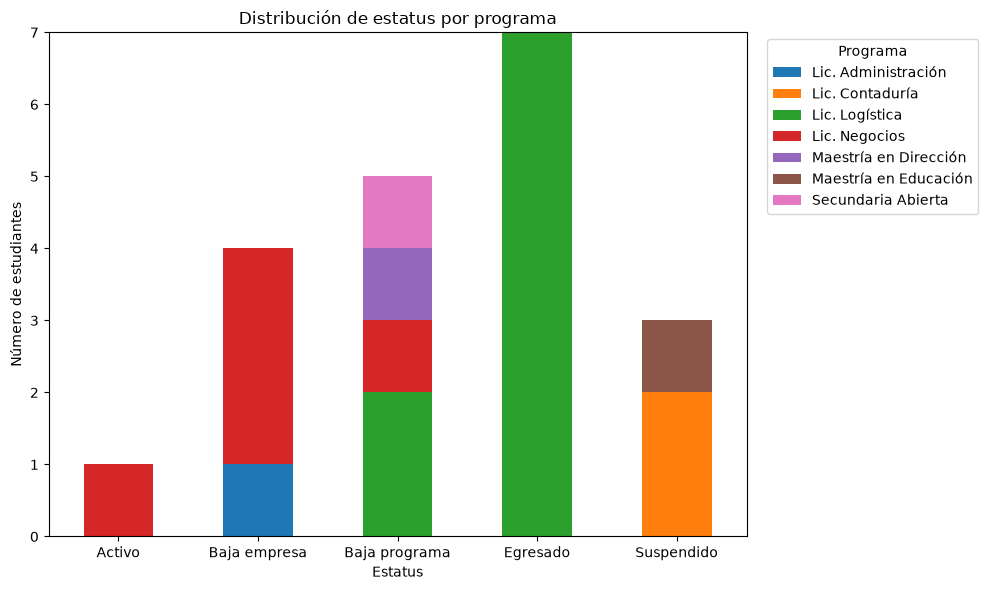

In [31]:
import matplotlib.pyplot as plt

status_distribution.T.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Distribución de estatus por programa")
plt.xlabel("Estatus")
plt.ylabel("Número de estudiantes")
plt.xticks(rotation=0)
plt.legend(title="Programa", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

In [32]:
## Visualización 2. Evolución mensual de altas y bajas

# Se presenta una gráfica de líneas que compara la cantidad de estudiantes que pasaron a estado activo contra aquellos que causaron baja por empresa o por programa en cada mes.

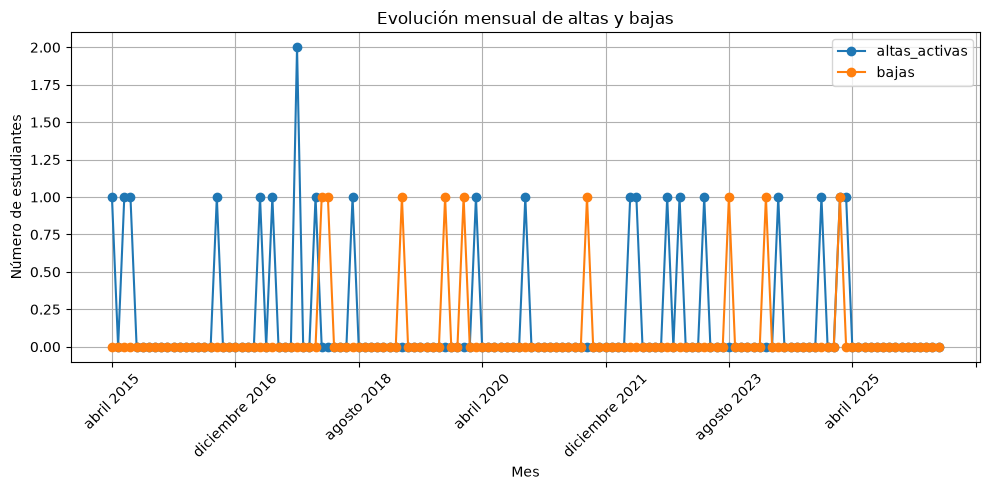

In [33]:
import matplotlib.pyplot as plt

monthly_trend.plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Evolución mensual de altas y bajas")
plt.xlabel("Mes")
plt.ylabel("Número de estudiantes")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [ ]:
## Conclusiones

- Lic. Logística concentra la mayor cantidad de egresos y también varias bajas por programa; en contraste, Lic. Negocios es el único programa con estudiantes activos visibles.
- En el análisis mensual, el pico de altas activas se observó en octubre de 2017 con 2 registros, mientras que las bajas alcanzaron su mayor valor en febrero de 2018 con 1 registro.
- Las bajas se explican principalmente por motivos de empresa, documentación o decisión del estudiante, así que el seguimiento debe enfocarse en esos puntos críticos para reducir la deserción.